# Predictive Process Monitoring

In [89]:
# Target Variable

sla_threshold = features["duration_hours"].median()

features["target_delay"] = (features["duration_hours"] > sla_threshold).astype(int)

In [90]:
# Train/Test Split

X = features[
    [
        "num_events",
        "unique_activities",
        "resource_count"
    ]
]

y = features["target_delay"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [91]:
# Random Forest Code

model_rf = RandomForestClassifier(   
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [92]:
# Predictions

predictions_rf = model_rf.predict(X_test)

In [93]:
# Evaluation

print("Random Forest Accuracy:")
print("Accuracy:", accuracy_score(y_test, predictions_rf))

print("\nClassification Report:")
print(classification_report(y_test, predictions_rf))

Random Forest Accuracy:
Accuracy: 0.6611913321548454

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.36      0.51     25136
           1       0.60      0.96      0.74     25211

    accuracy                           0.66     50347
   macro avg       0.75      0.66      0.63     50347
weighted avg       0.75      0.66      0.63     50347



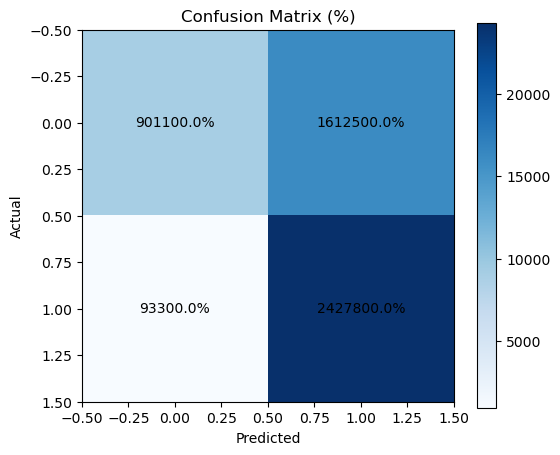

In [94]:
# Confusion Matrix Visualization

cm = confusion_matrix(y_test, predictions_rf)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix (%)")

plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add percentage text
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i,
                 f"{cm[i, j]*100:.1f}%",
                 ha='center',
                 va='center',
                 color='black')

plt.colorbar()
plt.show()

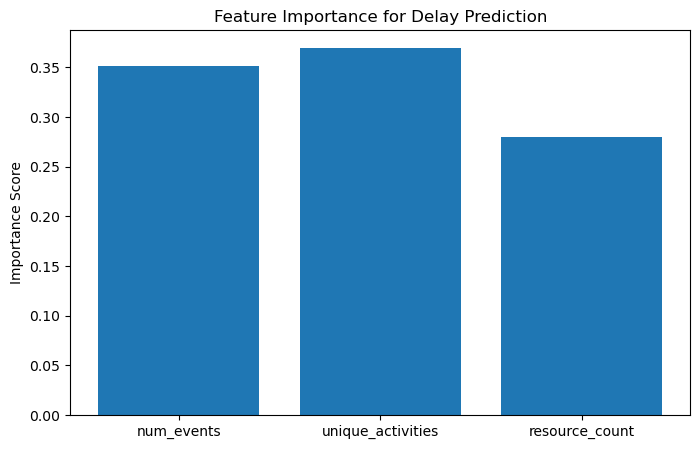

In [95]:
# Feature Importance Visualization

importance = model_rf.feature_importances_

feature_names = X.columns

plt.figure(figsize=(8,5))

plt.bar(feature_names, importance)

plt.title("Feature Importance for Delay Prediction")

plt.ylabel("Importance Score")

plt.show()